In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.feature_selection import mutual_info_regression

In [2]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

In [7]:
df = pd.read_csv('../data/features/features_complete.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nTarget variable: views")
print(f"Average views: {df['views'].mean():,.0f}")
print(f"Median views: {df['views'].median():,.0f}")

Dataset shape: (26678, 35)
Columns: ['Unnamed: 0', 'index', 'video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_date', 'time_frame', 'published_day_of_week', 'publish_country', 'tags', 'views', 'likes', 'dislikes', 'comment_count', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'category_name', 'is_published_weekend', 'trending_day_of_week', 'is_trending_weekend', 'hour_of_trending', 'days_until_trending', 'title_cleaned', 'is_english', 'title_length', 'uppercase_words', 'contains_numbers_or_emojis', 'num_emojis', 'has_emoji', 'emojis_list', 'sentiment_polarity', 'sentiment_subjectivity']

Target variable: views
Average views: 296,818
Median views: 159,198


In [ ]:
feature_cols = [
    'title_length',
    'uppercase_words',
    'contains_numbers_or_emojis',
    'sentiment_polarity',
    'sentiment_subjectivity'
]
available_features = [col for col in feature_cols if col in df.columns]
print(f"\nAvailable features for analysis: {len(available_features)}")
print(available_features)


Available features for analysis: 5
['title_length', 'uppercase_words', 'contains_numbers_or_emojis', 'sentiment_polarity', 'sentiment_subjectivity']


In [10]:
print("\n" + "="*70)
print("STEP 3: Correlation Analysis with Views")
print("="*70)

# Calculate correlations
correlations = []
for feature in available_features:
    # Remove any NaN values for this feature
    valid_data = df[[feature, 'views']].dropna()
    
    if len(valid_data) > 0:
        # Pearson correlation
        corr, p_value = pearsonr(valid_data[feature], valid_data['views'])
        
        correlations.append({
            'feature': feature,
            'correlation': corr,
            'abs_correlation': abs(corr),
            'p_value': p_value,
            'significant': p_value < 0.05
        })

corr_df = pd.DataFrame(correlations).sort_values('abs_correlation', ascending=False)

print("\n📊 Feature Correlations with Views:")
print("="*70)
for _, row in corr_df.iterrows():
    sig = "✓" if row['significant'] else "✗"
    print(f"{row['feature']:35s} | Corr: {row['correlation']:7.4f} | p-value: {row['p_value']:.4f} {sig}")


STEP 3: Correlation Analysis with Views

📊 Feature Correlations with Views:
uppercase_words                     | Corr: -0.1230 | p-value: 0.0000 ✓
sentiment_subjectivity              | Corr:  0.1019 | p-value: 0.0000 ✓
contains_numbers_or_emojis          | Corr: -0.0385 | p-value: 0.0000 ✓
title_length                        | Corr:  0.0138 | p-value: 0.0239 ✓
sentiment_polarity                  | Corr:  0.0015 | p-value: 0.8065 ✗



STEP 4: Visualizing Feature Importance


/var/folders/2_/5q5ttccx4_92gx1kdsq3smjh0000gn/T/ipykernel_30223/3085501861.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


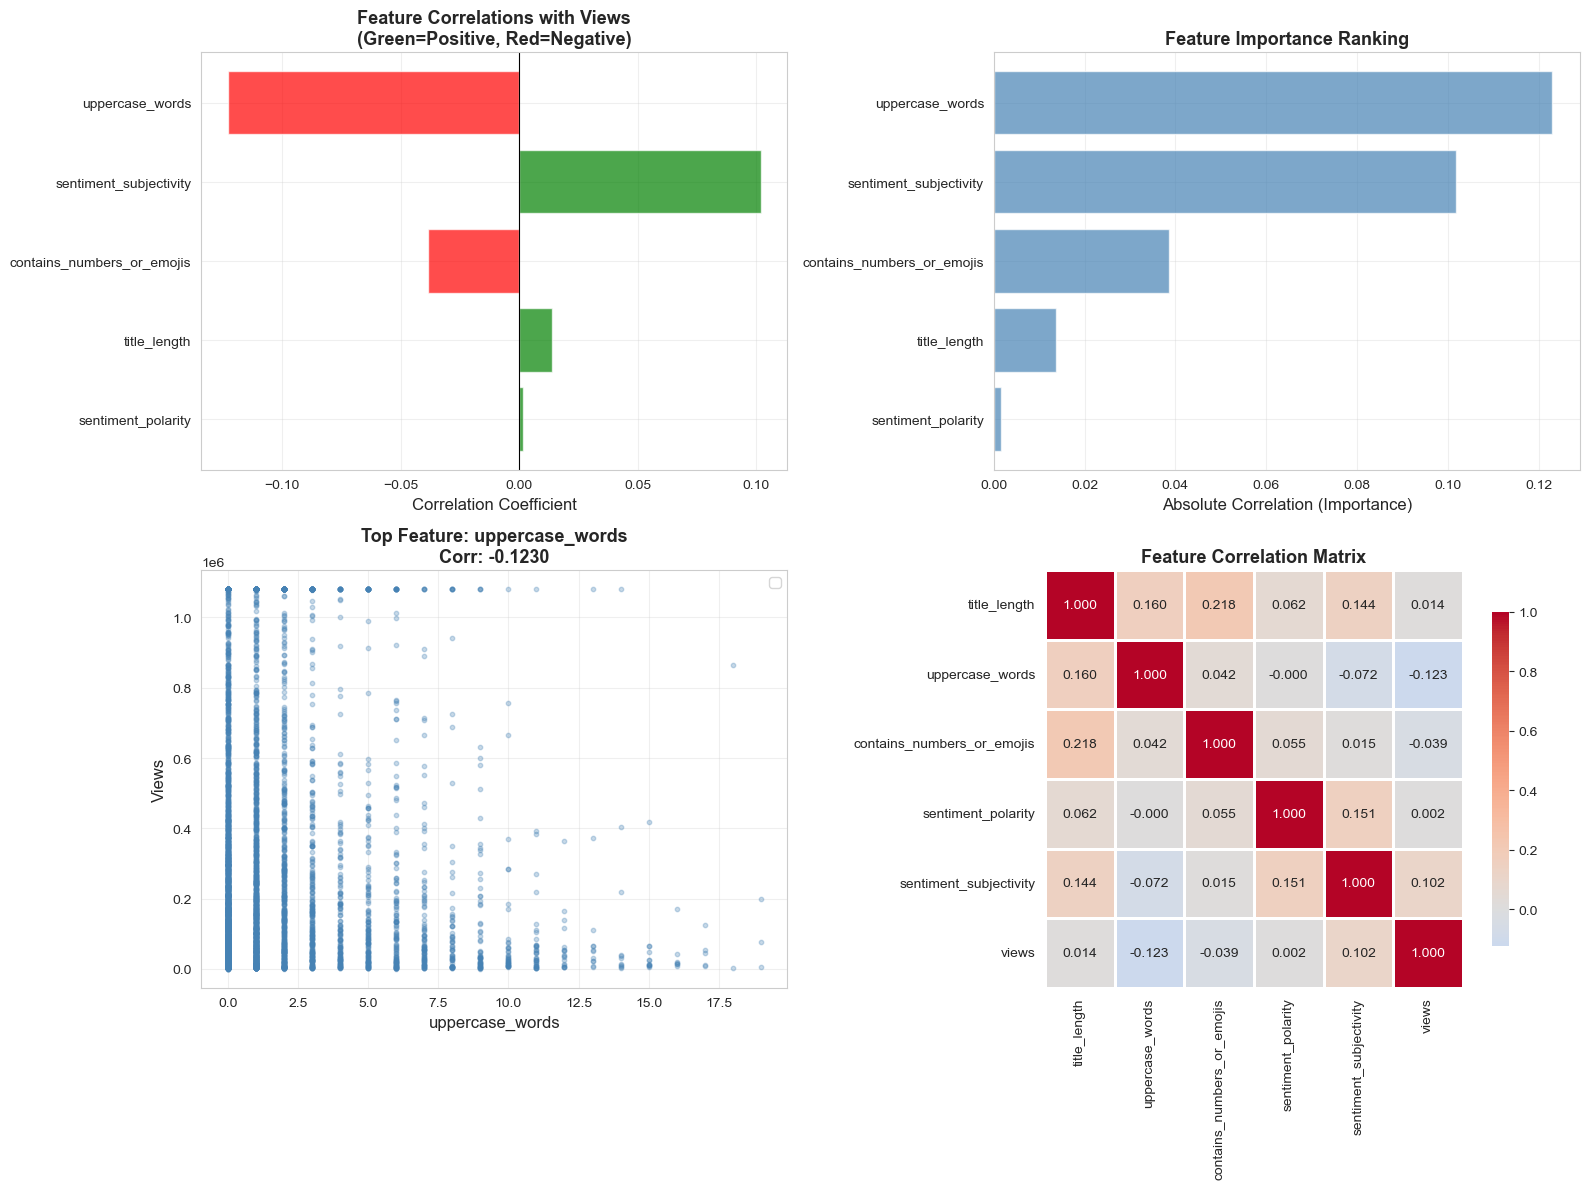

✅ Visualization saved: feature_importance_analysis.png


In [ ]:
print("\n" + "="*70)
print("STEP 4: Visualizing Feature Importance")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Correlation Bar Chart
ax = axes[0, 0]
colors = ['green' if x > 0 else 'red' for x in corr_df['correlation']]
ax.barh(range(len(corr_df)), corr_df['correlation'], color=colors, alpha=0.7)
ax.set_yticks(range(len(corr_df)))
ax.set_yticklabels(corr_df['feature'])
ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_title('Feature Correlations with Views\n(Green=Positive, Red=Negative)', 
             fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.invert_yaxis()
ax.grid(True, alpha=0.3)


# Plot 2: Absolute Correlation (Importance)
ax = axes[0, 1]
ax.barh(range(len(corr_df)), corr_df['abs_correlation'], color='steelblue', alpha=0.7)
ax.set_yticks(range(len(corr_df)))
ax.set_yticklabels(corr_df['feature'])
ax.set_xlabel('Absolute Correlation (Importance)', fontsize=12)
ax.set_title('Feature Importance Ranking', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

# Plot 3: Scatter plot of top feature
if len(corr_df) > 0:
    top_feature = corr_df.iloc[0]['feature']
    ax = axes[1, 0]
    
    # Sample data for plotting (to avoid overcrowding)
    sample_df = df.sample(min(5000, len(df)), random_state=42)
    
    ax.scatter(sample_df[top_feature], sample_df['views'], 
               alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel(top_feature, fontsize=12)
    ax.set_ylabel('Views', fontsize=12)
    ax.set_title(f'Top Feature: {top_feature}\nCorr: {corr_df.iloc[0]["correlation"]:.4f}',
                 fontsize=13, fontweight='bold')
    
    # Add trend line
    z = np.polyfit(sample_df[top_feature].fillna(0), sample_df['views'], 1)
    p = np.poly1d(z)
    ax.plot(sample_df[top_feature].fillna(0), 
            p(sample_df[top_feature].fillna(0)), 
            "r--", linewidth=2, alpha=0.8, label='Trend')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Plot 4: Correlation Heatmap
ax = axes[1, 1]
# Create correlation matrix for features + views
heatmap_cols = available_features + ['views']
corr_matrix = df[heatmap_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/features/feature_importance_analysis.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualization saved: feature_importance_analysis.png")

In [33]:
# Analyze each feature in detail

for feature in corr_df['feature']:
    print(f"\n{'='*70}")
    print(f"📊 Analyzing: {feature}")
    print('='*70)
    
    # Basic statistics
    print(f"\nDescriptive Statistics:")
    print(df[feature].describe())
    
    # Correlation details
    corr_info = corr_df[corr_df['feature'] == feature].iloc[0]
    print(f"\nCorrelation with views: {corr_info['correlation']:.4f}")
    print(f"P-value: {corr_info['p_value']:.6f}")
    print(f"Statistically significant: {'Yes ✓' if corr_info['significant'] else 'No ✗'}")
    
    # Practical interpretation
    if corr_info['correlation'] > 0.05:
        print(f"💡 Insight: Higher {feature} tends to associate with MORE views")
    elif corr_info['correlation'] < -0.05:
        print(f"💡 Insight: Higher {feature} tends to associate with FEWER views")
    else:
        print(f"💡 Insight: {feature} shows WEAK correlation with views")



📊 Analyzing: uppercase_words

Descriptive Statistics:
count    26678.000000
mean         1.691469
std          2.743946
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max         20.000000
Name: uppercase_words, dtype: float64

Correlation with views: -0.1230
P-value: 0.000000
Statistically significant: Yes ✓
💡 Insight: Higher uppercase_words tends to associate with FEWER views

📊 Analyzing: sentiment_subjectivity

Descriptive Statistics:
count    26678.000000
mean         0.242533
std          0.313457
min          0.000000
25%          0.000000
50%          0.000000
75%          0.487179
max          1.000000
Name: sentiment_subjectivity, dtype: float64

Correlation with views: 0.1019
P-value: 0.000000
Statistically significant: Yes ✓
💡 Insight: Higher sentiment_subjectivity tends to associate with MORE views

📊 Analyzing: contains_numbers_or_emojis

Descriptive Statistics:
count    26678.000000
mean         0.433316
std          0.495543
min


STEP 6: Feature Category Analysis


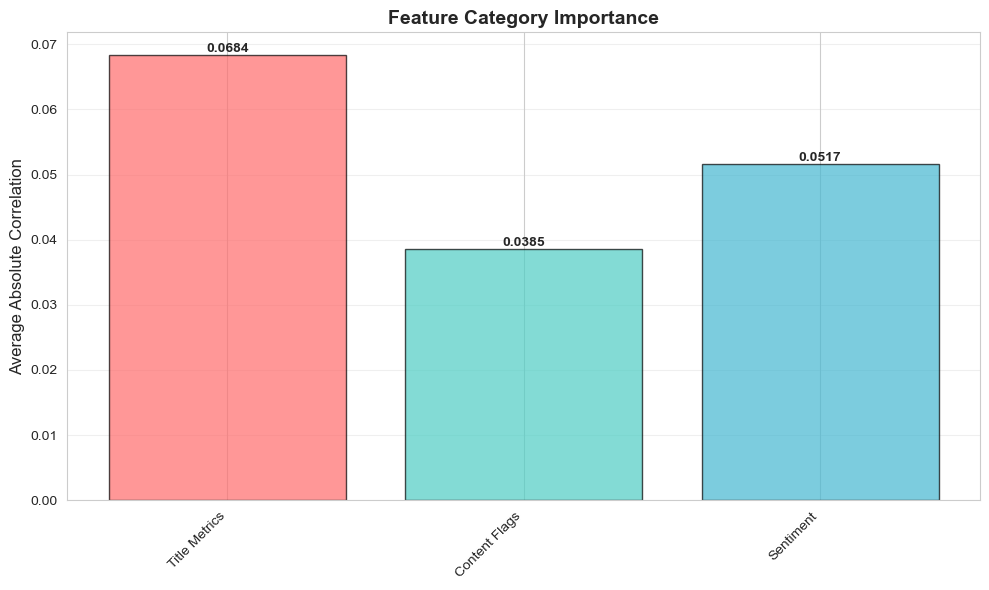

In [37]:
# ===== 6. FEATURE CATEGORIES ANALYSIS =====
print("\n" + "="*70)
print("STEP 6: Feature Category Analysis")
print("="*70)

# Group features by category
feature_categories = {
    'Title Metrics': ['title_length', 'uppercase_words'],
    'Content Flags': ['contains_numbers_or_emojis'],
    'Sentiment': ['sentiment_polarity', 'sentiment_subjectivity']
}

category_scores = {}
for category, features in feature_categories.items():
    category_features = [f for f in features if f in corr_df['feature'].values]
    if category_features:
        avg_importance = corr_df[corr_df['feature'].isin(category_features)]['abs_correlation'].mean()
        category_scores[category] = avg_importance

# Create category comparison plot
if category_scores:
    fig, ax = plt.subplots(figsize=(10, 6))
    categories = list(category_scores.keys())
    scores = list(category_scores.values())
    
    colors_map = {'Title Metrics': '#FF6B6B', 'Content Flags': '#4ECDC4', 
                  'Sentiment': '#45B7D1'}
    colors = [colors_map.get(cat, 'gray') for cat in categories]
    
    ax.bar(categories, scores, color=colors, alpha=0.7, edgecolor='black')
    ax.set_ylabel('Average Absolute Correlation', fontsize=12)
    ax.set_title('Feature Category Importance', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (cat, score) in enumerate(zip(categories, scores)):
        ax.text(i, score, f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../reports/features/category_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

In [38]:


print("\n🎯 TOP FINDINGS:")
print("="*70)

# Top positive correlations
positive_corr = corr_df[corr_df['correlation'] > 0]
if len(positive_corr) > 0:
    print("\n✅ Features POSITIVELY correlated with views:")
    for _, row in positive_corr.iterrows():
        print(f"   • {row['feature']:30s} | +{row['correlation']:.4f}")

# Top negative correlations  
negative_corr = corr_df[corr_df['correlation'] < 0]
if len(negative_corr) > 0:
    print("\n⚠️  Features NEGATIVELY correlated with views:")
    for _, row in negative_corr.iterrows():
        print(f"   • {row['feature']:30s} | {row['correlation']:.4f}")

# Weakest correlations
weak_corr = corr_df.nsmallest(2, 'abs_correlation')
print("\n🤔 Features with WEAK correlation:")
for _, row in weak_corr.iterrows():
    print(f"   • {row['feature']:30s} | {row['correlation']:.4f}")

print("\n" + "="*70)
print("💡 RECOMMENDATIONS FOR ML MODEL:")
print("="*70)

# Recommend features to keep
strong_features = corr_df[corr_df['abs_correlation'] > 0.01]['feature'].tolist()
print(f"\n✓ KEEP these features (strong correlation):")
for feat in strong_features:
    print(f"   • {feat}")

# Recommend features to consider dropping
weak_features = corr_df[corr_df['abs_correlation'] <= 0.01]['feature'].tolist()
if weak_features:
    print(f"\n✗ CONSIDER DROPPING (weak correlation):")
    for feat in weak_features:
        print(f"   • {feat}")





🎯 TOP FINDINGS:

✅ Features POSITIVELY correlated with views:
   • sentiment_subjectivity         | +0.1019
   • title_length                   | +0.0138
   • sentiment_polarity             | +0.0015

⚠️  Features NEGATIVELY correlated with views:
   • uppercase_words                | -0.1230
   • contains_numbers_or_emojis     | -0.0385

🤔 Features with WEAK correlation:
   • sentiment_polarity             | 0.0015
   • title_length                   | 0.0138

💡 RECOMMENDATIONS FOR ML MODEL:

✓ KEEP these features (strong correlation):
   • uppercase_words
   • sentiment_subjectivity
   • contains_numbers_or_emojis
   • title_length

✗ CONSIDER DROPPING (weak correlation):
   • sentiment_polarity
